**ENVIRONMENT SETUP**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# --- GPU MEMORY GROWTH ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# --- MIXED PRECISION ---
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# --- REPRODUCIBILITY ---
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Mixed Precision Policy: {tf.keras.mixed_precision.global_policy().name}")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed Precision Policy: mixed_float16


**CONFIGURATION**

In [ ]:
CONFIG = {
    # Model architecture
    "input_size": (224, 224, 3),
    "backbone": "efficientnet-b0",

    # Phase 1: Frozen backbone (feature learning)
    "phase1_batch_size": 64,
    "phase1_lr": 3e-4,
    "phase1_epochs": 12,

    # Phase 2: Fine-tuning
    "phase2_batch_size": 32,
    "phase2_lr": 1e-5,
    "phase2_epochs": 25,

    # Optimizer
    "weight_decay": 1e-5,

    # Focal Loss
    "focal_alpha": 0.65,
    "focal_gamma": 2.0,
    "label_smoothing": 0.05,

    # CBAM
    "cbam_reduction": 16,

    # Data paths
    "base_dir": "/content/drive/MyDrive/Glumoma2.0/GlumomaDataset/full-fundus",
    "train_dir": "/content/drive/MyDrive/Glumoma2.0/GlumomaDataset/full-fundus/train",
    "val_dir": "/content/drive/MyDrive/Glumoma2.0/GlumomaDataset/full-fundus/val",
    "test_dir": "/content/drive/MyDrive/Glumoma2.0/GlumomaDataset/full-fundus/test",

    # Save directory
    "save_dir": "/content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay",
}

USE_CLASS_WEIGHTS = False
os.makedirs(CONFIG["save_dir"], exist_ok=True)

CLASS_WEIGHT = {
    0: 1.0,   # normal
    1: 1.25   # glaucoma
}

RUN_ID = "9_may_glaucoma"
run_name = f"glaucoma_b0_{RUN_ID}"

print("✓ Configuration ready.")
print(f"  Input: {CONFIG['input_size']}")
print(f"  Backbone: {CONFIG['backbone']}")
print(f"  Phase 1: bs={CONFIG['phase1_batch_size']}, lr={CONFIG['phase1_lr']}, epochs={CONFIG['phase1_epochs']}")
print(f"  Phase 2: bs={CONFIG['phase2_batch_size']}, lr={CONFIG['phase2_lr']}, epochs={CONFIG['phase2_epochs']}")
print(f"  Run: {run_name}")

✓ Configuration ready.
  Input: (224, 224, 3)
  Backbone: efficientnet-b0
  Phase 1: bs=64, lr=0.0003, epochs=12
  Phase 2: bs=32, lr=1e-05, epochs=25
  Run: glaucoma_b0_9_may_glaucoma


**TEST AND VALIDATION DATASET COPY TO LOCAL DRIVE FOR FASTER IO**

In [ ]:
import shutil
import os

LOCAL_DATA_DIR = '/content/local_data'
DRIVE_BASE = '/content/drive/MyDrive/Glumoma2.0/GlumomaDataset'

def copy_to_local(src, dst):
    if not os.path.exists(dst):
        print(f"Copying {src} → {dst} ...")
        shutil.copytree(src, dst)
        print("Done.")
    else:
        print(f"Path {dst} already exists.")

copy_to_local(f'{DRIVE_BASE}/full-fundus/test', f'{LOCAL_DATA_DIR}/full-fundus/test')
copy_to_local(f'{DRIVE_BASE}/full-fundus/val',   f'{LOCAL_DATA_DIR}/full-fundus/val')

CONFIG['test_dir'] = f'{LOCAL_DATA_DIR}/full-fundus/test'
CONFIG['val_dir']   = f'{LOCAL_DATA_DIR}/full-fundus/val'

Copying /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/full-fundus/test → /content/local_data/full-fundus/test ...
Done.
Copying /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/full-fundus/val → /content/local_data/full-fundus/val ...
Done.


**LABEL ALIASES**

In [ ]:
POSITIVE_CLASS_ALIASES = {"glaucoma", "positive", "abnormal"}
NEGATIVE_CLASS_ALIASES = {"normal", "negative"}

def _normalize_class_name(name):
    return name.strip().lower().replace(" ", "_").replace("-", "_")

def resolve_binary_class_indices(class_names):
    normalized = [_normalize_class_name(c) for c in class_names]

    pos_hits = [i for i, c in enumerate(normalized) if c in POSITIVE_CLASS_ALIASES]
    neg_hits = [i for i, c in enumerate(normalized) if c in NEGATIVE_CLASS_ALIASES]

    if len(pos_hits) != 1:
        raise ValueError(f"Could not resolve exactly one positive class from: {class_names}")
    if len(neg_hits) != 1:
        raise ValueError(f"Could not resolve exactly one negative class from: {class_names}")

    return pos_hits[0], neg_hits[0]

**DATA LOADING**

In [ ]:
import tensorflow as tf

print("Loading datasets from Drive...")

IMG_SIZE = CONFIG["input_size"][:2]  # (224, 224)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CONFIG["val_dir"],
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=None,
    color_mode="rgb",
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    CONFIG["test_dir"],
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=None,
    color_mode="rgb",
    shuffle=False
)

class_names = list(val_ds_raw.class_names)
positive_class_idx, negative_class_idx = resolve_binary_class_indices(class_names)

POSITIVE_CLASS_NAME = class_names[positive_class_idx]
NEGATIVE_CLASS_NAME = class_names[negative_class_idx]

print(f"\nClasses: {class_names}")
print(f"Positive class: {POSITIVE_CLASS_NAME} -> 1")
print(f"Negative class: {NEGATIVE_CLASS_NAME} -> 0")
print("\n✓ Dataset loaded.")

Loading datasets from Drive...
Found 985 files belonging to 2 classes.
Found 2463 files belonging to 2 classes.

Classes: ['glaucoma', 'normal']
Positive class: glaucoma -> 1
Negative class: normal -> 0

✓ Dataset loaded.


**LABEL MAPPING & DATA PIPELINE**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def remap_to_binary(image, label):
    # Force: positive class = 1, negative class = 0
    label = tf.cast(label, tf.int32)
    label = tf.cast(tf.equal(label, positive_class_idx), tf.float32)
    return image, tf.expand_dims(label, axis=-1)

def build_eval_pipeline(ds_raw, batch_size):
    return (
        ds_raw
        .map(remap_to_binary, num_parallel_calls=AUTOTUNE)
        .batch(batch_size, drop_remainder=False)
        .prefetch(AUTOTUNE)
    )

print("✓ Evaluation pipeline ready.")

✓ Evaluation pipeline ready.


**CBAM ATTENTION MODULE**

In [ ]:
class ChannelAttention(layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        self.dense1 = None
        self.dense2 = None
        self.channels = None
        self.reduced_channels = None

    def build(self, input_shape):
        self.channels = int(input_shape[-1])
        self.reduced_channels = max(self.channels // self.reduction_ratio, 1)

        self.dense1 = layers.Dense(
            self.reduced_channels,
            activation="relu",
            kernel_initializer="he_normal",
            use_bias=True
        )
        self.dense2 = layers.Dense(
            self.channels,
            kernel_initializer="he_normal",
            use_bias=True
        )
        super().build(input_shape)

    def call(self, inputs):
        x = tf.cast(inputs, tf.float32)

        avg_pool = tf.reduce_mean(x, axis=[1, 2])
        max_pool = tf.reduce_max(x, axis=[1, 2])

        avg_out = self.dense2(self.dense1(avg_pool))
        max_out = self.dense2(self.dense1(max_pool))

        attention = tf.nn.sigmoid(avg_out + max_out)
        attention = tf.reshape(attention, [-1, 1, 1, self.channels])

        attention = tf.cast(attention, inputs.dtype)
        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({
            "reduction_ratio": self.reduction_ratio,
        })
        return config


class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = None

    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            padding="same",
            kernel_initializer="he_normal",
            use_bias=True
        )
        super().build(input_shape)

    def call(self, inputs):
        x = tf.cast(inputs, tf.float32)

        avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)

        attention = tf.nn.sigmoid(self.conv(concat))
        attention = tf.cast(attention, inputs.dtype)

        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_size": self.kernel_size,
        })
        return config


class CBAM(layers.Layer):
    def __init__(self, reduction_ratio=16, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        self.kernel_size = kernel_size

        self.channel_attention = ChannelAttention(
            reduction_ratio=reduction_ratio
        )

        self.spatial_attention = SpatialAttention(
            kernel_size=kernel_size
        )

    def build(self, input_shape):
        self.channel_attention.build(input_shape)
        self.spatial_attention.build(input_shape)
        super().build(input_shape)

    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "reduction_ratio": self.reduction_ratio,
            "kernel_size": self.kernel_size,
        })
        return config

print("✓ CBAM Attention Modules defined")

✓ CBAM Attention Modules defined


**CUSTOM FOCAL LOSS WITH LABEL SMOOTHING**

In [ ]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, label_smoothing=0.0,
                 reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
                 name="focal_loss", **kwargs):
        super().__init__(reduction=reduction, name=name, **kwargs)
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # label smoothing
        if self.label_smoothing > 0:
            y_true = y_true * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)

        alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)

        modulating_factor = tf.pow(1.0 - p_t, self.gamma)

        loss = -alpha_factor * modulating_factor * tf.math.log(p_t)
        return tf.squeeze(loss, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha,
            "gamma": self.gamma,
            "label_smoothing": self.label_smoothing,
        })
        return config

print("✓ Improved Focal Loss defined")

✓ Improved Focal Loss defined


**MODEL ARCHITECTURE**

In [ ]:
def build_glaucoma_model(config):

    inputs = layers.Input(shape=config["input_size"], name="input_image")

    # --- Backbone ---
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
        pooling=None
    )
    backbone.trainable = False

    x = backbone.output  # (None, 7, 7, 1280)

    # --- CBAM ---
    x = CBAM(
        reduction_ratio=config["cbam_reduction"],
        kernel_size=7,
        name="cbam"
    )(x)

    # --- Head ---
    x = layers.GlobalAveragePooling2D(name="gap")(x)

    # Block 1
    x1 = layers.Dense(512, kernel_initializer="he_normal")(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation("swish")(x1)
    x1 = layers.Dropout(0.4)(x1)

    # Block 2
    x2 = layers.Dense(256, kernel_initializer="he_normal")(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation("swish")(x2)
    x2 = layers.Dropout(0.3)(x2)

    # Residual connection
    res = layers.Dense(256, kernel_initializer="he_normal")(x)
    x = layers.Add()([x2, res])

    # Block 3
    x = layers.Dense(128, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)
    x = layers.Dropout(0.2)(x)

    # Output
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="output"
    )(x)

    return Model(inputs, outputs, name="GlaucomaDetector_v3")

**LOAD TRAINED MODEL**

In [ ]:
phase2_best_path = os.path.join(
    CONFIG["save_dir"],
    f"{run_name}_p2_best.keras"
)

print(f"Loading trained model from: {phase2_best_path}")

model = keras.models.load_model(
    phase2_best_path,
    custom_objects={
        "CBAM": CBAM,
        "ChannelAttention": ChannelAttention,
        "SpatialAttention": SpatialAttention,
        "FocalLoss": FocalLoss
    },
    compile=False
)

print("✓ Loaded trained model")

Loading trained model from: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_p2_best.keras
✓ Loaded trained model


**VALIDATION THRESHOLD SELECTION TARGETTING SENSITIVITY**

In [ ]:
import json
import numpy as np
from sklearn.metrics import roc_curve, auc

def collect_probs_and_labels(model, ds):
    y_true = []
    y_prob = []

    for x_batch, y_batch in ds:
        probs = model(x_batch, training=False)
        y_true.append(y_batch.numpy().reshape(-1))
        y_prob.append(probs.numpy().reshape(-1))

    return np.concatenate(y_true), np.concatenate(y_prob)

def select_threshold_for_sensitivity(y_true, y_prob, target_sensitivity=0.90):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    valid = np.where(tpr >= target_sensitivity)[0]

    if len(valid) > 0:
        # Among thresholds that meet target sensitivity, choose the one with best specificity
        best_idx = valid[np.argmax(1 - fpr[valid])]
    else:
        # Fallback: choose the threshold with the highest sensitivity
        best_idx = int(np.argmax(tpr))

    optimal_threshold = float(thresholds[best_idx])
    sensitivity = float(tpr[best_idx])
    specificity = float(1 - fpr[best_idx])

    return optimal_threshold, float(roc_auc), sensitivity, specificity

print("=" * 60)
print(" VALIDATION THRESHOLD SELECTION ")
print("=" * 60)

# Validation dataset
val_eval_ds = build_eval_pipeline(val_ds_raw, CONFIG["phase2_batch_size"])

# Collect probabilities
y_true_val, y_prob_val = collect_probs_and_labels(model, val_eval_ds)

# Select threshold for screening sensitivity
target_sensitivity = 0.90
optimal_threshold, roc_auc, val_sensitivity, val_specificity = select_threshold_for_sensitivity(
    y_true_val,
    y_prob_val,
    target_sensitivity=target_sensitivity
)

print(f"Validation ROC AUC        : {roc_auc:.4f}")
print(f"Target Sensitivity        : {target_sensitivity:.2f}")
print(f"Selected Threshold        : {optimal_threshold:.4f}")
print(f"Sensitivity at Threshold  : {val_sensitivity:.4f}")
print(f"Specificity at Threshold  : {val_specificity:.4f}")

# Save threshold
threshold_path = os.path.join(
    CONFIG["save_dir"],
    f"{run_name}_threshold.json"
)

threshold_payload = {
    "optimal_threshold": optimal_threshold,
    "validation_auc": float(roc_auc),
    "validation_sensitivity": float(val_sensitivity),
    "validation_specificity": float(val_specificity),
    "selection_method": f"target_sensitivity_{target_sensitivity:.2f}"
}

with open(threshold_path, "w") as f:
    json.dump(threshold_payload, f, indent=2)

print(f"\n✓ Threshold saved to: {threshold_path}")

 VALIDATION THRESHOLD SELECTION 
Validation ROC AUC        : 0.9409
Target Sensitivity        : 0.90
Selected Threshold        : 0.3898
Sensitivity at Threshold  : 0.9003
Specificity at Threshold  : 0.7831

✓ Threshold saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_threshold.json


**EVALUATION & SAVING**

In [ ]:
import json
import numpy as np
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    average_precision_score
)

def collect_probs_and_labels(model, ds):
    y_true = []
    y_prob = []

    for x_batch, y_batch in ds:
        probs = model(x_batch, training=False)
        y_true.append(y_batch.numpy().reshape(-1))
        y_prob.append(probs.numpy().reshape(-1))

    return np.concatenate(y_true), np.concatenate(y_prob)

print("Evaluating on test set...")

# frozen validation-selected threshold
threshold_path = os.path.join(CONFIG["save_dir"], f"{run_name}_threshold.json")
with open(threshold_path, "r") as f:
    threshold_data = json.load(f)

threshold = float(threshold_data["optimal_threshold"])
print(f"Using frozen validation threshold: {threshold:.4f}")

eval_batch_size = CONFIG.get("phase2_batch_size", 8)
test_ds = build_eval_pipeline(test_ds_raw, eval_batch_size)

y_true, y_prob = collect_probs_and_labels(model, test_ds)
y_pred = (y_prob >= threshold).astype(np.int32)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
specificity = tn / (tn + fp) if (tn + fp) else 0.0
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_true, y_prob)

print("\nTest confusion matrix:")
print(cm)
print(f"\nSensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"ROC AUC    : {roc_auc:.4f}")
print(f"PR AUC     : {pr_auc:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
        digits=4
    )
)

# Save final model
final_model_path = os.path.join(CONFIG["save_dir"], f"{run_name}_final.keras")
model.save(final_model_path)
print(f"\n✓ Final model saved to: {final_model_path}")

# Save weights separately
weights_path = os.path.join(CONFIG["save_dir"], f"{run_name}_weights.weights.h5")
model.save_weights(weights_path)
print(f"✓ Weights saved to: {weights_path}")

# Save config + results + threshold
results_path = os.path.join(CONFIG["save_dir"], f"{run_name}_test_results.json")
results_payload = {
    "threshold": threshold,
    "confusion_matrix": cm.tolist(),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "positive_class": POSITIVE_CLASS_NAME,
    "negative_class": NEGATIVE_CLASS_NAME,
    "model_path": final_model_path,
    "weights_path": weights_path
}
with open(results_path, "w") as f:
    json.dump(results_payload, f, indent=2)

config_path = os.path.join(CONFIG["save_dir"], f"{run_name}_config.txt")
with open(config_path, "w") as f:
    f.write("Training Configuration\n" + "=" * 50 + "\n")
    for key, value in CONFIG.items():
        f.write(f"{key}: {value}\n")
    f.write("\n" + "=" * 50 + "\n")
    f.write(f"Threshold: {threshold:.6f}\n")
    f.write(f"Sensitivity: {sensitivity:.6f}\n")
    f.write(f"Specificity: {specificity:.6f}\n")
    f.write(f"ROC AUC: {roc_auc:.6f}\n")
    f.write(f"PR AUC: {pr_auc:.6f}\n")
    f.write("\n" + "=" * 50 + "\n")
    f.write("Test Results\n" + "=" * 50 + "\n")
    f.write(f"TN: {tn}\nFP: {fp}\nFN: {fn}\nTP: {tp}\n")

print(f"✓ Config saved to: {config_path}")
print(f"✓ Test results saved to: {results_path}")

Evaluating on test set...
Using frozen validation threshold: 0.3898

Test confusion matrix:
[[1182  328]
 [  87  866]]

Sensitivity: 0.9087
Specificity: 0.7828
ROC AUC    : 0.9437
PR AUC     : 0.9244

Classification report:
              precision    recall  f1-score   support

      normal     0.9314    0.7828    0.8507      1510
    glaucoma     0.7253    0.9087    0.8067       953

    accuracy                         0.8315      2463
   macro avg     0.8284    0.8457    0.8287      2463
weighted avg     0.8517    0.8315    0.8337      2463


✓ Final model saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_final.keras
✓ Weights saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_weights.weights.h5
✓ Config saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_config.txt
✓ Test results saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaData

**LOAD TRAINING LOGS & PLOT HISTORY**

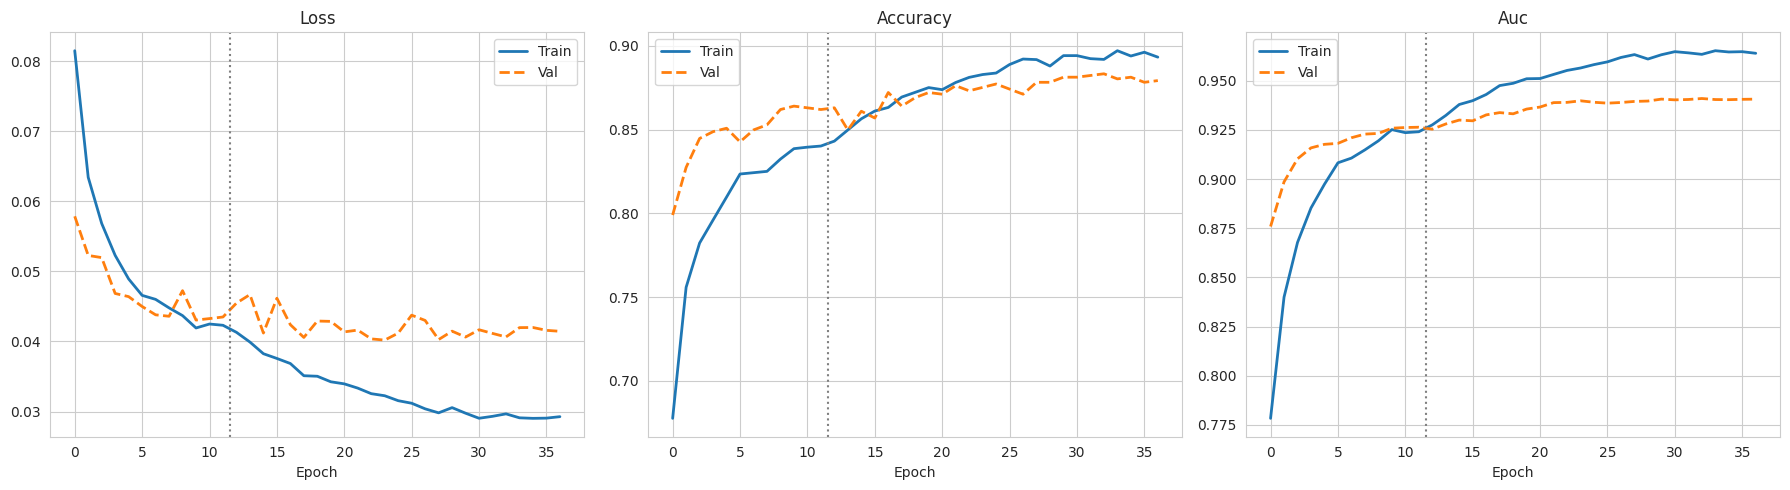

Saved plot to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_history_from_csv.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

p1_log = os.path.join(CONFIG["save_dir"], f"{run_name}_p1_log.csv")
p2_log = os.path.join(CONFIG["save_dir"], f"{run_name}_p2_log.csv")

df1 = pd.read_csv(p1_log)
df2 = pd.read_csv(p2_log)

# merge histories
history_df = pd.concat([df1, df2], ignore_index=True)

metrics = ["loss", "accuracy", "auc"]

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))

if len(metrics) == 1:
    axes = [axes]

phase1_epochs = len(df1)

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    ax.plot(history_df[metric], label="Train", linewidth=2)

    val_metric = f"val_{metric}"
    if val_metric in history_df.columns:
        ax.plot(
            history_df[val_metric],
            label="Val",
            linewidth=2,
            linestyle="--"
        )

    ax.axvline(
        x=phase1_epochs - 0.5,
        color="gray",
        linestyle=":"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()

save_path = os.path.join(
    CONFIG["save_dir"],
    f"{run_name}_history_from_csv.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {save_path}")

**ROC & PRECISION-RECALL CURVES**

✓ Curves saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_curves.png


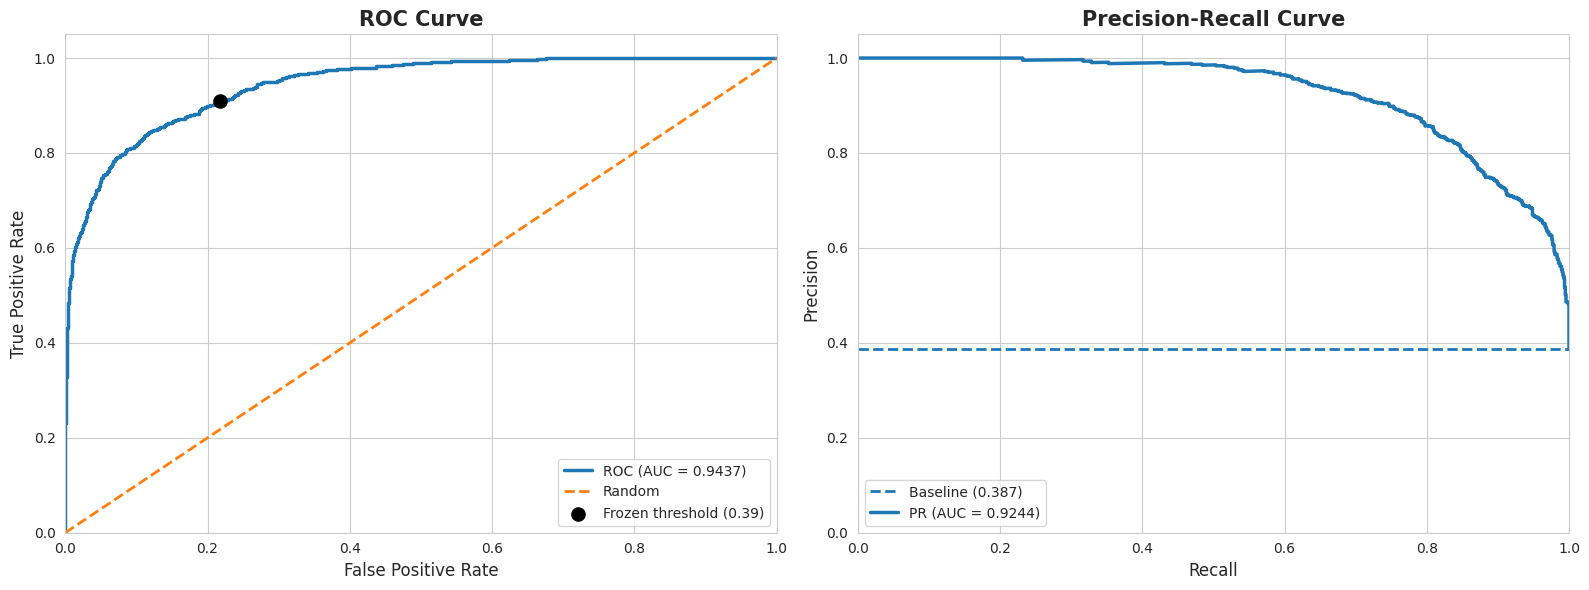

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    confusion_matrix
)

if "run_name" not in globals():
    run_name = "glaucoma_b0_9_may_glaucoma"

# Get threshold from saved validation result, or fall back to memory
threshold_path = os.path.join(CONFIG["save_dir"], f"{run_name}_threshold.json")
if os.path.exists(threshold_path):
    with open(threshold_path, "r") as f:
        optimal_threshold = float(json.load(f)["optimal_threshold"])
elif "optimal_threshold" in globals():
    optimal_threshold = float(globals()["optimal_threshold"])
elif "threshold" in globals():
    optimal_threshold = float(threshold)
else:
    raise ValueError("No frozen threshold found. Run validation-threshold selection first.")

# Reuse cached test predictions if available, otherwise collect them
if "y_true" not in globals() or "y_prob" not in globals():
    if "test_ds" not in globals():
        test_ds = build_eval_pipeline(test_ds_raw, CONFIG["phase2_batch_size"])
    y_true, y_prob = collect_probs_and_labels(model, test_ds)

y_true = np.asarray(y_true).reshape(-1)
y_prob = np.asarray(y_prob).reshape(-1)

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Operating point at the frozen threshold
y_pred = (y_prob >= optimal_threshold).astype(np.int32)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
op_fpr = fp / (fp + tn) if (fp + tn) else 0.0
op_tpr = tp / (tp + fn) if (tp + fn) else 0.0

# Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, linewidth=2.5, label=f"ROC (AUC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random")
ax1.scatter(
    op_fpr, op_tpr,
    marker="o", s=90, color="black",
    label=f"Frozen threshold ({optimal_threshold:.2f})",
    zorder=5
)
ax1.set_xlim(0.0, 1.0)
ax1.set_ylim(0.0, 1.05)
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
ax1.set_title("ROC Curve", fontsize=15, fontweight="bold")
ax1.legend(loc="lower right")

positive_rate = np.mean(y_true)

ax2.hlines(
    positive_rate,
    xmin=0,
    xmax=1,
    linestyles="--",
    linewidth=2,
    label=f"Baseline ({positive_rate:.3f})"
)
ax2.plot(recall_vals, precision_vals, linewidth=2.5, label=f"PR (AUC = {pr_auc:.4f})")
ax2.set_xlim(0.0, 1.0)
ax2.set_ylim(0.0, 1.05)
ax2.set_xlabel("Recall", fontsize=12)
ax2.set_ylabel("Precision", fontsize=12)
ax2.set_title("Precision-Recall Curve", fontsize=15, fontweight="bold")
ax2.legend(loc="lower left")

plt.tight_layout()
save_path = os.path.join(CONFIG["save_dir"], f"{run_name}_curves.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"✓ Curves saved to: {save_path}")
plt.show()

curve_data = {
    "fpr": fpr.tolist(),
    "tpr": tpr.tolist(),
    "precision": precision_vals.tolist(),
    "recall": recall_vals.tolist(),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "threshold": float(optimal_threshold)
}

with open(
    os.path.join(CONFIG["save_dir"], f"{run_name}_curve_data.json"),
    "w"
) as f:
    json.dump(curve_data, f, indent=2)

**CONFUSION MATRIX & MEDICAL REPORT**

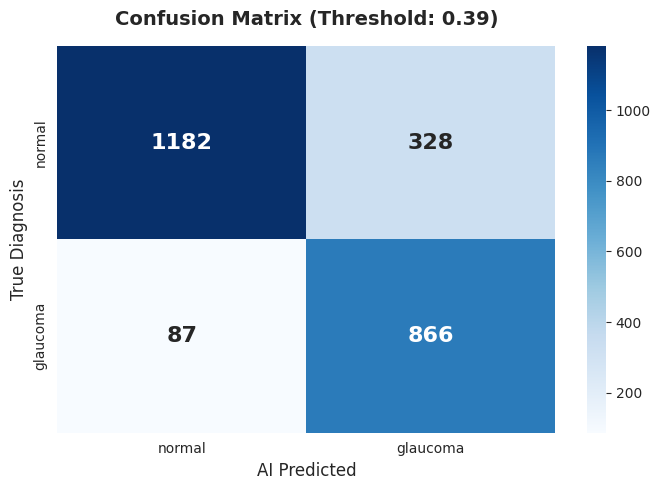


                 MEDICAL EVALUATION REPORT                  
Optimal Threshold : 0.3898
Sensitivity       : 0.9087  (% glaucoma caught)
Specificity       : 0.7828  (% normal cleared)
ROC AUC           : 0.9437
------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      normal     0.9314    0.7828    0.8507      1510
    glaucoma     0.7253    0.9087    0.8067       953

    accuracy                         0.8315      2463
   macro avg     0.8284    0.8457    0.8287      2463
weighted avg     0.8517    0.8315    0.8337      2463



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.metrics import roc_auc_score

# Make sure predictions exist from the frozen validation threshold
if "y_true" not in globals() or "y_prob" not in globals():
    if "test_ds" not in globals():
        test_ds = build_eval_pipeline(test_ds_raw, CONFIG["phase2_batch_size"])
    y_true, y_prob = collect_probs_and_labels(model, test_ds)

y_true = np.asarray(y_true).reshape(-1)
y_prob = np.asarray(y_prob).reshape(-1)


roc_auc = roc_auc_score(y_true, y_prob)

y_pred_optimal = (y_prob >= optimal_threshold).astype(np.int32)

cm = confusion_matrix(y_true, y_pred_optimal, labels=[0, 1])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
    yticklabels=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
    annot_kws={"size": 16, "weight": "bold"}
)
plt.title(
    f"Confusion Matrix (Threshold: {optimal_threshold:.2f})",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.ylabel("True Diagnosis", fontsize=12)
plt.xlabel("AI Predicted", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], f"{run_name}_confusion.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print("\n" + "=" * 60)
print(" MEDICAL EVALUATION REPORT ".center(60))
print("=" * 60)
print(f"Optimal Threshold : {optimal_threshold:.4f}")
print(f"Sensitivity       : {sensitivity:.4f}  (% glaucoma caught)")
print(f"Specificity       : {specificity:.4f}  (% normal cleared)")
print(f"ROC AUC           : {roc_auc:.4f}")
print("-" * 60)
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred_optimal,
        labels=[0, 1],
        target_names=[NEGATIVE_CLASS_NAME, POSITIVE_CLASS_NAME],
        digits=4
    )
)

**BOOTSTRAP CONFIDENCE INTERVALS ON TEST METRICS**

In [ ]:
import json
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

if "y_true" not in globals() or "y_prob" not in globals() or "optimal_threshold" not in globals():
    raise ValueError("y_true, y_prob, and optimal_threshold must already exist in memory.")

y_true = np.asarray(y_true).reshape(-1).astype(np.int32)
y_prob = np.asarray(y_prob).reshape(-1).astype(np.float32)
y_pred = (y_prob >= float(optimal_threshold)).astype(np.int32)

# Point estimates
point_metrics = {
    "roc_auc": float(roc_auc_score(y_true, y_prob)),
    "pr_auc": float(average_precision_score(y_true, y_prob)),
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "precision": float(precision_score(y_true, y_pred, zero_division=0)),
    "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
    "f1": float(f1_score(y_true, y_pred, zero_division=0)),
}

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
point_metrics["specificity"] = float(tn / (tn + fp)) if (tn + fp) else 0.0

# Bootstrap
rng = np.random.default_rng(42)
n_bootstraps = 2000
n = len(y_true)

boot = {
    "roc_auc": [],
    "pr_auc": [],
    "accuracy": [],
    "precision": [],
    "recall_sensitivity": [],
    "specificity": [],
    "f1": [],
}

for _ in range(n_bootstraps):
    idx = rng.integers(0, n, size=n)
    yt = y_true[idx]
    yp = y_prob[idx]
    yhat = (yp >= float(optimal_threshold)).astype(np.int32)

    # Skip resamples that contain only one class
    if len(np.unique(yt)) < 2:
        continue

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()

    boot["roc_auc"].append(roc_auc_score(yt, yp))
    boot["pr_auc"].append(average_precision_score(yt, yp))
    boot["accuracy"].append(accuracy_score(yt, yhat))
    boot["precision"].append(precision_score(yt, yhat, zero_division=0))
    boot["recall_sensitivity"].append(recall_score(yt, yhat, zero_division=0))
    boot["specificity"].append((tn_b / (tn_b + fp_b)) if (tn_b + fp_b) else 0.0)
    boot["f1"].append(f1_score(yt, yhat, zero_division=0))

def ci(arr, alpha=0.05):
    arr = np.asarray(arr, dtype=np.float64)
    return {
        "mean": float(np.mean(arr)),
        "lower": float(np.quantile(arr, alpha / 2)),
        "upper": float(np.quantile(arr, 1 - alpha / 2)),
        "n_boot": int(len(arr)),
    }

ci_metrics = {k: ci(v) for k, v in boot.items()}

print("=" * 70)
print(" BOOTSTRAP 95% CONFIDENCE INTERVALS ".center(70))
print("=" * 70)

for k in ["roc_auc", "pr_auc", "accuracy", "precision", "recall_sensitivity", "specificity", "f1"]:
    p = point_metrics[k]
    c = ci_metrics[k]
    print(f"{k:20s}: {p:.4f}  (95% CI {c['lower']:.4f} – {c['upper']:.4f})")

# Save results
bootstrap_path = os.path.join(CONFIG["save_dir"], f"{run_name}_bootstrap_ci.json")
payload = {
    "optimal_threshold": float(optimal_threshold),
    "point_metrics": point_metrics,
    "bootstrap_ci": ci_metrics,
    "n_bootstraps_requested": n_bootstraps,
}
with open(bootstrap_path, "w") as f:
    json.dump(payload, f, indent=2)

print(f"\n✓ Bootstrap CI saved to: {bootstrap_path}")

                  BOOTSTRAP 95% CONFIDENCE INTERVALS                  
roc_auc             : 0.9437  (95% CI 0.9343 – 0.9522)
pr_auc              : 0.9244  (95% CI 0.9113 – 0.9360)
accuracy            : 0.8315  (95% CI 0.8165 – 0.8465)
precision           : 0.7253  (95% CI 0.6998 – 0.7504)
recall_sensitivity  : 0.9087  (95% CI 0.8899 – 0.9261)
specificity         : 0.7828  (95% CI 0.7617 – 0.8033)
f1                  : 0.8067  (95% CI 0.7877 – 0.8251)

✓ Bootstrap CI saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_bootstrap_ci.json


**CALIBRATION ANALYSIS & BRIER SCORE**

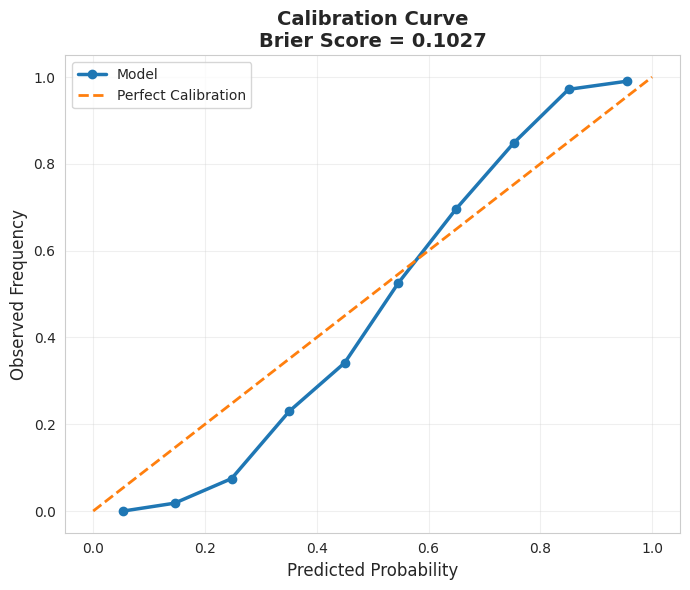

 CALIBRATION ANALYSIS 
Brier Score: 0.102729
✓ Calibration plot saved to: /content/drive/MyDrive/Glumoma2.0/GlumomaDataset/models/NineMay/glaucoma_b0_9_may_glaucoma_calibration.png
✓ Calibration metrics saved


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Ensure arrays
y_true = np.asarray(y_true).reshape(-1)
y_prob = np.asarray(y_prob).reshape(-1)

# Brier score
brier = brier_score_loss(y_true, y_prob)

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2.5,
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect Calibration"
)

plt.xlabel("Predicted Probability", fontsize=12)
plt.ylabel("Observed Frequency", fontsize=12)

plt.title(
    f"Calibration Curve\nBrier Score = {brier:.4f}",
    fontsize=14,
    fontweight="bold"
)

plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()

save_path = os.path.join(
    CONFIG["save_dir"],
    f"{run_name}_calibration.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("=" * 60)
print(" CALIBRATION ANALYSIS ")
print("=" * 60)
print(f"Brier Score: {brier:.6f}")
print(f"✓ Calibration plot saved to: {save_path}")

# Save metrics
calibration_payload = {
    "brier_score": float(brier),
    "prob_true": prob_true.tolist(),
    "prob_pred": prob_pred.tolist()
}

with open(
    os.path.join(CONFIG["save_dir"], f"{run_name}_calibration.json"),
    "w"
) as f:
    json.dump(calibration_payload, f, indent=2)

print("✓ Calibration metrics saved")